<a href="https://colab.research.google.com/github/anug1/ECS260_data_gathering_processing/blob/main/Nonforked_Lime_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install lime xgboost scikit-learn

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
import pandas as pd
import pickle
from lime.lime_tabular import LimeTabularExplainer

from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, recall_score, roc_auc_score

from xgboost import XGBClassifier
from lime.lime_tabular import LimeTabularExplainer

import matplotlib.pyplot as plt


In [23]:
df = pd.read_csv("final_dataset_nonfork.csv", low_memory=False)

print(df.shape)
print(df.head())


(47292, 41)
                               repo_name  is_fork fork_owner_type  \
0                BenoitBotton/gltfImport    False            User   
1               simjae97/javateamproject    False            User   
2                        hs3city/orpheus    False    Organization   
3            julianarhk/androidStudioIFC    False            User   
4  TamaraPerez82/Entregable1_PerezTamara    False            User   

                  created_at  total_commits  commit_frequency_per_week  \
0  2024-01-17 11:30:55+00:00              2                   0.076923   
1  2024-01-31 06:31:57+00:00            100                   3.846154   
2  2023-12-01 09:16:16+00:00              3                   0.115385   
3  2023-12-25 14:39:59+00:00              0                   0.000000   
4  2024-01-12 13:30:44+00:00              3                   0.115385   

   unique_commit_authors  issues_opened  issues_closed  issue_close_rate  ...  \
0                      1              0        

In [24]:
y = df['is_sustainable']

X = df.drop(columns=[
    'is_sustainable',
    'repo_name',
    'created_at',
    'topics',
    'parent_repo',
    'parent_created_at',
    'parent_language',
    'parent_stars',
    'parent_forks',
    'parent_early_commits',
    'early_commits_on_branch',
    'divergence_ratio',
    'is_fork'
])

print("Shape after drop:", X.shape)

Shape after drop: (47292, 28)


In [25]:
numerical_cols = X.select_dtypes(include=["number"]).columns
categorical_cols = X.select_dtypes(include=["object","bool"]).columns

for col in numerical_cols:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

for col in X.select_dtypes(include=["bool"]).columns:
    X[col] = X[col].astype(int)

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", X.shape)

Shape after encoding: (47292, 237)


/tmp/ipykernel_193/1691690302.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].fillna(X[col].mode()[0])


In [26]:
language_cols = X.filter(regex="primary_language_|parent_language_").columns

top_languages = X[language_cols].sum().sort_values(ascending=False).head(10).index

X = X.drop(columns=[col for col in language_cols if col not in top_languages])

print("Shape after language reduction:", X.shape)


Shape after language reduction: (47292, 37)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(37833, 37) (9459, 37)


In [28]:
class_counts = y_train.value_counts()
neg_count = class_counts[0]
pos_count = class_counts[1]

scale_pos_weight = neg_count / pos_count

print("scale_pos_weight:", scale_pos_weight)

xgb_model_balanced = XGBClassifier(
    random_state=42,
    eval_metric=['logloss','auc','error'],
    scale_pos_weight=scale_pos_weight
)

xgb_model_balanced.fit(X_train, y_train)

print("Model trained.")

scale_pos_weight: 6.155853981463968
Model trained.


In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, recall_score, roc_auc_score, precision_score
from xgboost import XGBClassifier
from IPython.display import display


# Train model (same as before)
class_counts = y_train.value_counts()
neg_count = class_counts[0]
pos_count = class_counts[1]

scale_pos_weight = neg_count / pos_count

xgb_model_balanced = XGBClassifier(
    random_state=42,
    eval_metric=['logloss','auc','error'],
    scale_pos_weight=scale_pos_weight
)

xgb_model_balanced.fit(X_train, y_train)

# Get probabilities once
y_scores = xgb_model_balanced.predict_proba(X_test)[:, 1]

# AUC stays constant
auc = roc_auc_score(y_test, y_scores)

# Define thresholds (your "k")
thresholds = [0.3, 0.5, 0.7]

results = []

for t in thresholds:
    y_pred = (y_scores >= t).astype(int)

    results.append({
        "k": round(t, 2),
        "Precision": precision_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

print("AUC:", round(auc, 4))
display(results_df)


AUC: 0.95


,k,Precision,F1,Recall
0,0.3,0.580523,0.707176,0.904515
1,0.5,0.671478,0.754460,0.860844
2,0.7,0.730535,0.763083,0.798668


In [30]:
X_sample = X.sample(1000, random_state=42)

explainer = LimeTabularExplainer(
    training_data=X_sample.values,
    feature_names=X.columns.tolist(),
    class_names=["Not Sustainable","Sustainable"],
    mode="classification"
)

print("LIME ready")

LIME ready


In [31]:
import numpy as np
from collections import defaultdict
import re

# --- Robust feature cleaner (FIXES "19.00" BUG) ---
def clean_feature(feature):
    parts = re.split(r'<=|>=|<|>|=', feature)

    for p in parts:
        p = p.strip()
        # return the part that is NOT just a number
        if not re.match(r'^\d+(\.\d+)?$', p):
            return p
    return feature  # fallback


# --- Storage ---
importance_sum = defaultdict(float)
abs_importance_sum = defaultdict(float)
count = defaultdict(int)
pos_count = defaultdict(int)

# --- Reproducibility ---
np.random.seed(42)

# --- Sample from TEST data (correct) ---
sample_indices = np.random.choice(len(X_test), 100, replace=False)

# --- LIME aggregation ---
for i in sample_indices:

    exp = explainer.explain_instance(
        X_test.values[i],
        xgb_model_balanced.predict_proba,
        num_features=20,
        num_samples=1000
    )

    weights = np.array([abs(w) for _, w in exp.as_list()])
    total = weights.sum()

    for feature, weight in exp.as_list():

        # FIXED FEATURE EXTRACTION
        feature_name = clean_feature(feature)

        # NORMALIZATION (critical)
        norm_weight = weight / total if total > 0 else 0

        # Aggregate
        importance_sum[feature_name] += norm_weight
        abs_importance_sum[feature_name] += abs(norm_weight)
        count[feature_name] += 1

        if weight > 0:
            pos_count[feature_name] += 1

In [32]:
import pandas as pd

# --- Final aggregation ---
results = {}

for f in importance_sum:
    # Handle division by zero for pos_ratio if count[f] is 0
    pos_ratio_val = pos_count[f] / count[f] if count[f] > 0 else 0
    results[f] = {
        "mean_signed": importance_sum[f] / count[f],
        "mean_abs": abs_importance_sum[f] / count[f],
        "pos_ratio": pos_ratio_val,
        "count": count[f]
    }


# --- Convert to DataFrame (for plotting) ---
lime_df = pd.DataFrame.from_dict(results, orient='index').reset_index()
lime_df = lime_df.rename(columns={'index': 'Feature'})

# Sort by importance
lime_df = lime_df.sort_values(by="mean_abs", ascending=False)

print(lime_df.head(20))

                              Feature  mean_signed  mean_abs  pos_ratio  count
0                          bus_factor    -0.108150  0.243387   0.255556     90
1                          has_cicd_1    -0.045521  0.090219   0.250000    100
9                       issues_opened     0.057914  0.065827   0.920000    100
4                  has_contributing_1    -0.048844  0.061040   0.103093     97
3         primary_language_JavaScript    -0.000398  0.058774   0.510000    100
6                        num_releases     0.036917  0.043877   0.916667     96
24              unique_commit_authors     0.000254  0.040330   0.726190     84
2                primary_language_C++    -0.021468  0.040122   0.289474     76
14               total_issue_comments    -0.027705  0.039987   0.164948     97
5                       has_license_1    -0.017698  0.039079   0.275510     98
29               primary_language_CSS     0.032522  0.037903   0.893939     66
22                primary_language_Go    -0.002354  

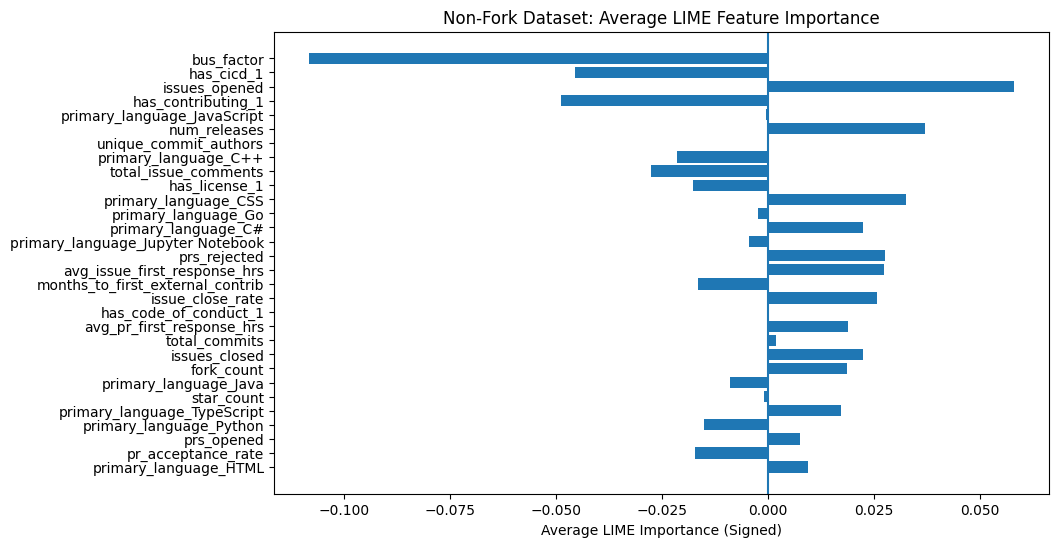

In [33]:
import matplotlib.pyplot as plt

top_features = lime_df.head(30) # lime_df is already sorted by mean_abs

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["mean_signed"]
)

plt.axvline(0)  # zero line for positive/negative split
plt.xlabel("Average LIME Importance (Signed)")
plt.title("Non-Fork Dataset: Average LIME Feature Importance")
plt.gca().invert_yaxis()

plt.show()